# Pythonセミナー第9回：QM9のHOMO-LUMOギャップ予測 v2

このノートブックは、v1と同じ特徴量とXGBoost設定を使い、検証方法だけを3-fold交差検証へ変更します。

外部データ、事前学習済みモデル、LLM、NNPは使用しません。

評価指標はMAE、乱数シードはスライド推奨の8、提出ファイルは `smiles,gap_eV` の2列とします。

In [1]:
# 数値計算、表形式データ、可視化に使うライブラリを読み込む
from pathlib import Path
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rdkit
import seaborn as sns
import sklearn
import xgboost as xgb
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Descriptors, rdFingerprintGenerator
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold
from tqdm import tqdm

# スライドで推奨されている乱数シード8を、分割とモデルの両方に使用する
SEED = 8
np.random.seed(SEED)

# ノートブックをプロジェクト直下から実行する前提で入出力パスを定義する
PROJECT_DIR = Path.cwd()
TRAIN_PATH = PROJECT_DIR / "qm9_bandgap_train.csv"
TEST_PATH = PROJECT_DIR / "qm9_bandgap_test_without_answer.csv"
SUBMISSION_PATH = PROJECT_DIR / "submissionv2.csv"

# 再現性を確認できるように、実行環境と主要ライブラリの版を表示する
print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"RDKit: {rdkit.__version__}")
print(f"XGBoost: {xgb.__version__}")

Python: 3.11.15
pandas: 3.0.3
scikit-learn: 1.9.0
RDKit: 2026.03.4
XGBoost: 3.2.0


## 1. 配布CSVの読込と検査

訓練データは `smiles,gap_eV`、テストデータは `smiles` の列を持つことを確認します。

同じ分子が異なるfoldへ分かれるとMAEが過度によく見えるため、Canonical SMILESを使って重複も調べます。

In [2]:
# 配布されたCSVだけを読み込み、外部データは追加しない
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# スライドで指定された列構造になっているかを早い段階で検査する
assert train_df.columns.tolist() == ["smiles", "gap_eV"]
assert test_df.columns.tolist() == ["smiles"]
assert train_df["smiles"].notna().all()
assert train_df["gap_eV"].notna().all()
assert test_df["smiles"].notna().all()

# 行数、目的変数の範囲、先頭行を表示してデータの読込結果を確認する
print(f"訓練データ: {train_df.shape}")
print(f"テストデータ: {test_df.shape}")
print(
    "gap_eVの範囲: "
    f"{train_df['gap_eV'].min():.6f} ～ {train_df['gap_eV'].max():.6f} eV"
)
display(train_df.head())
display(test_df.head())

訓練データ: (15000, 2)
テストデータ: (4000, 1)
gap_eVの範囲: 1.774183 ～ 10.718570 eV


,smiles,gap_eV
0,C#CC1(CNC1=O)C#C,7.094012
1,CC1CC=CCOC=N1,6.854552
2,CC1=C2CCC3C(C1)C23,5.839566
3,COC(=O)CN1CC1C,6.658630
4,OC1CC23CCCC12O3,8.364784


,smiles
0,CC1(CN1)C(C#C)C#N
1,C1CC11C2OC2C11CO1
2,OC1CC1C1CC(O)C1
3,OC1C=CC2COC12
4,CC1OC1CNC(N)=O


In [3]:
# SMILESをRDKitで読み、同じ分子を同じ文字列にそろえる関数を定義する
def canonicalize_smiles(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"RDKitで解釈できないSMILESです: {smiles}")
    return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)


# 訓練データとテストデータを同じ規則でCanonical SMILESへ変換する
train_df["canonical_smiles"] = train_df["smiles"].map(canonicalize_smiles)
test_df["canonical_smiles"] = test_df["smiles"].map(canonicalize_smiles)

# 同じ分子に異なる正解値が付いていないことを確認する
target_counts = train_df.groupby("canonical_smiles")["gap_eV"].nunique()
assert target_counts.max() == 1

# 重複分子数と、訓練データとテストデータの重なりを確認する
duplicate_rows = int(train_df.duplicated("canonical_smiles").sum())
train_test_overlap = set(train_df["canonical_smiles"]) & set(test_df["canonical_smiles"])
print(f"訓練データ内の重複行数: {duplicate_rows}")
print(f"訓練データとテストデータの分子重複数: {len(train_test_overlap)}")

# 検証時の漏洩を避けるため、正解値が同じ重複分子は1行だけ残す
model_df = train_df.drop_duplicates("canonical_smiles").reset_index(drop=True)
print(f"モデル学習に使う一意な分子数: {len(model_df)}")

訓練データ内の重複行数: 2
訓練データとテストデータの分子重複数: 0
モデル学習に使う一意な分子数: 14998


## 2. SMILESから特徴量を生成

一つ目の特徴量は、分子量、環数、極性などを数値化したRDKitの2次元分子記述子です。

二つ目の特徴量は、各原子の周囲にある局所構造を数えるMorganカウントフィンガープリントです。

QM9の分子は小さいため、局所構造が何回現れるかを残すカウント型を採用します。

配布CSVには3次元座標がないため、v2でも3次元構造を生成せず、SMILESだけから再現できる特徴量に限定します。

In [4]:
# Morganフィンガープリントの設定を固定する
MORGAN_RADIUS = 2
MORGAN_SIZE = 2048
MORGAN_GENERATOR = rdFingerprintGenerator.GetMorganGenerator(
    radius=MORGAN_RADIUS,
    fpSize=MORGAN_SIZE,
    includeChirality=True,
)

# Morgan密度は別途追加するフィンガープリントと重複するため、RDKit記述子から除外する
DESCRIPTOR_ITEMS = [
    (name, func)
    for name, func in Descriptors._descList
    if not name.startswith("FpDensityMorgan")
]
DESCRIPTOR_NAMES = [name for name, _ in DESCRIPTOR_ITEMS]

# 元素数と結合数を直接表す補助特徴量の名前を定義する
GRAPH_FEATURE_NAMES = [
    "graph_heavy_atoms",
    "graph_total_atoms_with_implicit_h",
    "graph_bonds",
    "graph_C_count",
    "graph_N_count",
    "graph_O_count",
    "graph_F_count",
    "graph_aromatic_atoms",
    "graph_ring_atoms",
    "graph_formal_charge",
    "graph_single_bonds",
    "graph_double_bonds",
    "graph_triple_bonds",
    "graph_aromatic_bonds",
    "graph_conjugated_bonds",
]

# 重要度を確認できるように、フィンガープリント位置にも名前を付ける
MORGAN_FEATURE_NAMES = [f"morgan_count_{i:04d}" for i in range(MORGAN_SIZE)]
FEATURE_NAMES = DESCRIPTOR_NAMES + GRAPH_FEATURE_NAMES + MORGAN_FEATURE_NAMES

print(f"RDKit分子記述子: {len(DESCRIPTOR_NAMES)}")
print(f"補助グラフ特徴量: {len(GRAPH_FEATURE_NAMES)}")
print(f"Morgan特徴量: {len(MORGAN_FEATURE_NAMES)}")
print(f"合計特徴量: {len(FEATURE_NAMES)}")

RDKit分子記述子: 214
補助グラフ特徴量: 15
Morgan特徴量: 2048
合計特徴量: 2277


In [5]:
# 一つの分子から、記述子、グラフ特徴量、Morganフィンガープリントを生成する
def featurize_molecule(smiles: str) -> np.ndarray:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"RDKitで解釈できないSMILESです: {smiles}")

    # RDKitが提供する2次元分子記述子を同じ順序で計算する
    descriptor_values = np.asarray(
        [float(func(mol)) for _, func in DESCRIPTOR_ITEMS],
        dtype=np.float64,
    )

    # QM9に含まれる元素組成、結合種、芳香族性を数える
    atomic_numbers = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
    bonds = list(mol.GetBonds())
    graph_values = np.asarray(
        [
            mol.GetNumHeavyAtoms(),
            sum(1 + atom.GetTotalNumHs() for atom in mol.GetAtoms()),
            mol.GetNumBonds(),
            atomic_numbers.count(6),
            atomic_numbers.count(7),
            atomic_numbers.count(8),
            atomic_numbers.count(9),
            sum(atom.GetIsAromatic() for atom in mol.GetAtoms()),
            sum(atom.IsInRing() for atom in mol.GetAtoms()),
            sum(atom.GetFormalCharge() for atom in mol.GetAtoms()),
            sum(bond.GetBondType() == Chem.BondType.SINGLE for bond in bonds),
            sum(bond.GetBondType() == Chem.BondType.DOUBLE for bond in bonds),
            sum(bond.GetBondType() == Chem.BondType.TRIPLE for bond in bonds),
            sum(bond.GetBondType() == Chem.BondType.AROMATIC for bond in bonds),
            sum(bond.GetIsConjugated() for bond in bonds),
        ],
        dtype=np.float64,
    )

    # 部分構造の有無だけでなく出現回数を残すMorganカウント型を計算する
    morgan_counts = MORGAN_GENERATOR.GetCountFingerprintAsNumPy(mol).astype(np.float64)

    # すべての特徴量を一つの固定長ベクトルへ連結する
    return np.concatenate([descriptor_values, graph_values, morgan_counts])


# SMILES列全体を、行が分子、列が特徴量の行列へ変換する
def build_feature_matrix(smiles_values, label: str) -> np.ndarray:
    rows = [
        featurize_molecule(smiles)
        for smiles in tqdm(
            smiles_values, desc=label, mininterval=5.0, miniters=500
        )
    ]
    matrix = np.vstack(rows)

    # 記述子計算で無限大が生じた場合は欠損値に置き換え、後段で補完できるようにする
    matrix[~np.isfinite(matrix)] = np.nan
    return matrix.astype(np.float32)


# 一意な訓練分子と、提出順を保ったテスト分子の特徴量を作る
X_all = build_feature_matrix(model_df["canonical_smiles"], "訓練特徴量")
X_test = build_feature_matrix(test_df["canonical_smiles"], "テスト特徴量")
y_all = model_df["gap_eV"].to_numpy(dtype=np.float32)

# 行数、列数、欠損値数を表示し、特徴量生成が想定どおりか確認する
assert X_all.shape == (len(model_df), len(FEATURE_NAMES))
assert X_test.shape == (len(test_df), len(FEATURE_NAMES))
print(f"訓練特徴量: {X_all.shape}")
print(f"テスト特徴量: {X_test.shape}")
print(f"訓練特徴量内の欠損値: {int(np.isnan(X_all).sum())}")
print(f"テスト特徴量内の欠損値: {int(np.isnan(X_test).sum())}")

テスト特徴量: 100%|██████████| 4000/4000 [00:29<00:00, 134.17it/s]

訓練特徴量: (14998, 2277)
テスト特徴量: (4000, 2277)
訓練特徴量内の欠損値: 0
テスト特徴量内の欠損値: 0


## 3. 3-fold交差検証とXGBoostの学習

一意な分子をシード8で3分割し、各foldを一度ずつ検証用にします。

欠損値の補完値は各foldの学習用データだけから求め、検証用データの情報が学習へ混ざらないようにします。

XGBoostの学習率、木の深さ、正則化、最大木数、早期停止条件はv1から変更しません。

3回の学習で得たout-of-fold予測から全体のMAEを求め、fold別最良木数の中央値を最終モデルへ使います。

In [6]:
# v1のXGBoost設定を変更せず、すべてのfoldと最終学習で共通して使う
XGB_PARAMS = {
    "objective": "reg:squarederror",
    "eval_metric": "mae",
    "learning_rate": 0.03,
    "max_depth": 7,
    "min_child_weight": 2.0,
    "subsample": 0.90,
    "colsample_bytree": 0.75,
    "reg_alpha": 0.0,
    "reg_lambda": 2.0,
    "tree_method": "hist",
    "random_state": SEED,
    "n_jobs": -1,
}

N_SPLITS = 3
MAX_ESTIMATORS = 4000
EARLY_STOPPING_ROUNDS = 150

# 各分子を一度だけ検証用に回し、out-of-fold予測を保存する
fold_splitter = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
oof_prediction = np.full(len(y_all), np.nan, dtype=np.float32)
fold_records = []
fold_feature_importances = []

for fold_number, (train_indices, valid_indices) in enumerate(
    fold_splitter.split(X_all),
    start=1,
):
    # 補完値は、このfoldの学習用特徴量だけから計算する
    fold_imputer = SimpleImputer(strategy="median", keep_empty_features=True)
    X_train = fold_imputer.fit_transform(X_all[train_indices]).astype(np.float32)
    X_valid = fold_imputer.transform(X_all[valid_indices]).astype(np.float32)
    y_train = y_all[train_indices]
    y_valid = y_all[valid_indices]

    # 最大4000本まで木を追加し、検証MAEが150回改善しなければ学習を止める
    fold_model = xgb.XGBRegressor(
        n_estimators=MAX_ESTIMATORS,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        **XGB_PARAMS,
    )
    fold_model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False,
    )

    valid_prediction = fold_model.predict(X_valid)
    fold_mae = mean_absolute_error(y_valid, valid_prediction)
    fold_best_rounds = int(fold_model.best_iteration) + 1
    oof_prediction[valid_indices] = valid_prediction
    fold_feature_importances.append(fold_model.feature_importances_)
    fold_records.append(
        {
            "fold": fold_number,
            "train_size": len(train_indices),
            "valid_size": len(valid_indices),
            "best_rounds": fold_best_rounds,
            "fold_mae": fold_mae,
        }
    )

    stop_status = (
        "早期停止"
        if fold_best_rounds < MAX_ESTIMATORS
        else f"上限{MAX_ESTIMATORS}本に到達"
    )
    print(
        f"fold {fold_number}/{N_SPLITS}: "
        f"MAE={fold_mae:.6f} eV, "
        f"最良木数={fold_best_rounds}（{stop_status}）"
    )

# 全分子に予測が一つずつ入ったことを確認し、交差検証全体のMAEを計算する
assert np.isfinite(oof_prediction).all()
fold_results = pd.DataFrame(fold_records)
oof_mae = mean_absolute_error(y_all, oof_prediction)
best_rounds = int(fold_results["best_rounds"].median())

display(fold_results)
print(f"OOF MAE: {oof_mae:.6f} eV")
print(
    "fold別MAE: "
    f"平均={fold_results['fold_mae'].mean():.6f} eV, "
    f"標準偏差={fold_results['fold_mae'].std(ddof=1):.6f} eV"
)
print(f"最終学習に使う木の本数: {best_rounds}（fold別最良木数の中央値）")

fold 1/3: MAE=0.203529 eV, 最良木数=3999（早期停止）
fold 2/3: MAE=0.204877 eV, 最良木数=3999（早期停止）
fold 3/3: MAE=0.199715 eV, 最良木数=4000（上限4000本に到達）


,fold,train_size,valid_size,best_rounds,fold_mae
0,1,9998,5000,3999,0.203529
1,2,9999,4999,3999,0.204877
2,3,9999,4999,4000,0.199715


OOF MAE: 0.202707 eV
fold別MAE: 平均=0.202707 eV, 標準偏差=0.002678 eV
最終学習に使う木の本数: 3999（fold別最良木数の中央値）


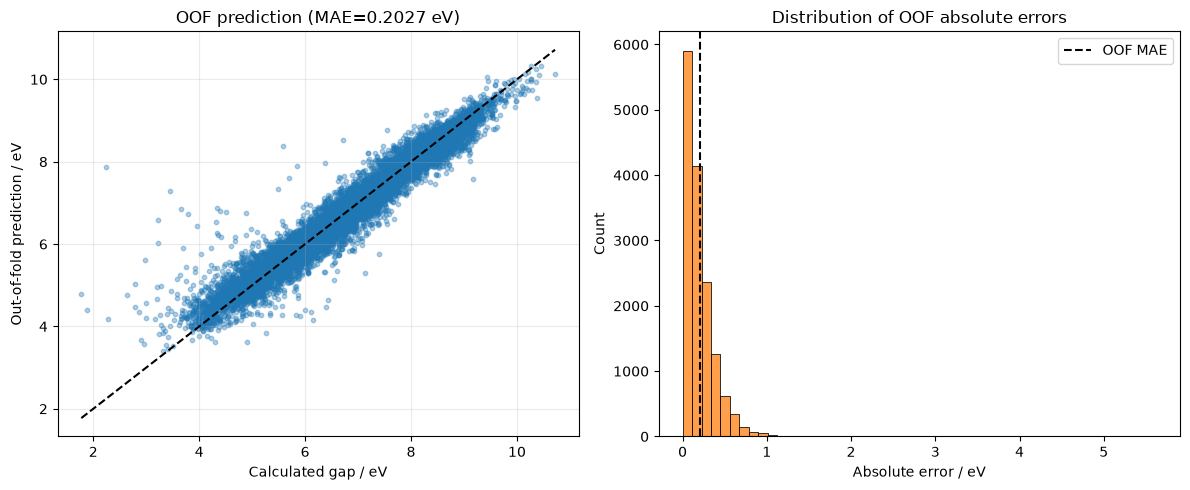

In [7]:
# out-of-fold予測の散布図と絶対誤差の分布を表示する
absolute_errors = np.abs(y_all - oof_prediction)
plot_min = float(min(y_all.min(), oof_prediction.min()))
plot_max = float(max(y_all.max(), oof_prediction.max()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左図では、点が対角線に近いほど予測が正確である
axes[0].scatter(y_all, oof_prediction, s=10, alpha=0.35, color="#1f77b4")
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "k--", linewidth=1.5)
axes[0].set_xlabel("Calculated gap / eV")
axes[0].set_ylabel("Out-of-fold prediction / eV")
axes[0].set_title(f"OOF prediction (MAE={oof_mae:.4f} eV)")
axes[0].grid(alpha=0.25)

# 右図では、誤差の大きい分子がどの程度あるかを確認する
sns.histplot(absolute_errors, bins=50, ax=axes[1], color="#ff7f0e")
axes[1].axvline(oof_mae, color="black", linestyle="--", label="OOF MAE")
axes[1].set_xlabel("Absolute error / eV")
axes[1].set_title("Distribution of OOF absolute errors")
axes[1].legend()

plt.tight_layout()
plt.show()

,feature,importance
102,FractionCSP3,0.139913
225,graph_double_bonds,0.130707
228,graph_conjugated_bonds,0.108565
38,HallKierAlpha,0.043082
221,graph_aromatic_atoms,0.035927
180,fr_ketone,0.033413
227,graph_aromatic_bonds,0.030754
49,PEOE_VSA14,0.027611
156,fr_amide,0.014934
903,morgan_count_0674,0.013735


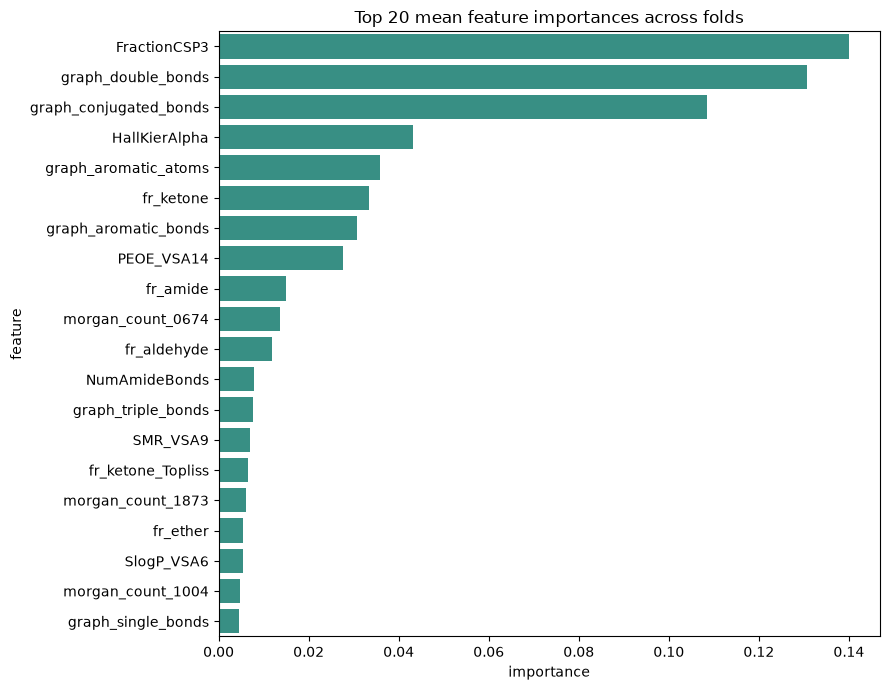

In [8]:
# 3個のfoldモデルの重要度を平均し、寄与の大きい上位20特徴量を確認する
mean_feature_importance = np.mean(fold_feature_importances, axis=0)
importance_df = pd.DataFrame(
    {
        "feature": FEATURE_NAMES,
        "importance": mean_feature_importance,
    }
).sort_values("importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(9, 7))
sns.barplot(
    data=importance_df.head(20),
    x="importance",
    y="feature",
    color="#2a9d8f",
)
plt.title("Top 20 mean feature importances across folds")
plt.tight_layout()
plt.show()

## 4. 全訓練データで学習し、提出CSVを作成

3個のfoldで得た最良木数の中央値を固定し、正解値を持つ一意な全分子を使ってモデルをゼロから学習し直します。

テストデータのSMILES順を変えずに予測値を付け、`submissionv2.csv` として保存します。

In [9]:
# 最終学習では、欠損値の補完値を一意な全訓練データから計算する
final_imputer = SimpleImputer(strategy="median", keep_empty_features=True)
X_full = final_imputer.fit_transform(X_all).astype(np.float32)
X_test_final = final_imputer.transform(X_test).astype(np.float32)

# 交差検証で決めた本数の木を持つXGBoostを、全訓練データからゼロから学習する
final_model = xgb.XGBRegressor(
    n_estimators=best_rounds,
    **XGB_PARAMS,
)
final_model.fit(X_full, y_all, verbose=False)

# 学習済み最終モデルの予測値だけを提出値として使用する
test_prediction = final_model.predict(X_test_final)

# 元のテストCSVのSMILESと行順をそのまま残し、gap_eV列を追加する
submission = test_df[["smiles"]].copy()
submission["gap_eV"] = test_prediction.astype(float)

# スライド指定の列名、行数、順序、有限値を保存前に検査する
assert submission.columns.tolist() == ["smiles", "gap_eV"]
assert len(submission) == len(test_df)
assert submission["smiles"].equals(test_df["smiles"])
assert np.isfinite(submission["gap_eV"]).all()

# 提出用CSVはインデックス列を付けずに保存する
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"保存先: {SUBMISSION_PATH}")
print(f"提出行数: {len(submission)}")
print(
    "予測値の範囲: "
    f"{submission['gap_eV'].min():.6f} ～ {submission['gap_eV'].max():.6f} eV"
)
display(submission.head())

保存先: /Users/f-kazuma/Developer/Python_seminer/9th/submissionv2.csv
提出行数: 4000
予測値の範囲: 3.624182 ～ 9.656155 eV


,smiles,gap_eV
0,CC1(CN1)C(C#C)C#N,7.301484
1,C1CC11C2OC2C11CO1,8.231664
2,OC1CC1C1CC(O)C1,8.614432
3,OC1C=CC2COC12,6.637933
4,CC1OC1CNC(N)=O,8.118256


In [10]:
# 保存したCSVを読み直し、ファイルとして壊れていないことを最終確認する
saved_submission = pd.read_csv(SUBMISSION_PATH)
assert saved_submission.columns.tolist() == ["smiles", "gap_eV"]
assert len(saved_submission) == len(test_df)
assert saved_submission["smiles"].equals(test_df["smiles"])
assert np.allclose(saved_submission["gap_eV"], submission["gap_eV"])

print("submissionv2.csvの再読込検査に合格しました。")

submissionv2.csvの再読込検査に合格しました。


## 口頭説明用の要点

- SMILESから生成する特徴量とXGBoostの学習条件はv1と同じです。

- 変更点は、単一の80%対20%分割をシード8の3-fold交差検証へ置き換えたことです。

- 各分子のout-of-fold予測からMAEを計算し、foldによる変動も確認します。

- fold別最良木数の中央値を使って全訓練データでモデルを学習し直し、テストデータ4,000件の `gap_eV` を予測します。